<a href="https://colab.research.google.com/github/Wasup1st/Asteri-Neuro-AI/blob/main/Asteri_NeuroAI_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install the converter that turns folders into 3D volumes
!apt-get install -y dcm2niix

# Install the Python library for viewing 3D brain data
!pip install nibabel

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libturbojpeg libyaml-cpp0.7
The following NEW packages will be installed:
  dcm2niix libturbojpeg libyaml-cpp0.7
0 upgraded, 3 newly installed, 0 to remove and 42 not upgraded.
Need to get 529 kB of archives.
After this operation, 1,877 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libturbojpeg amd64 2.1.2-0ubuntu1 [175 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libyaml-cpp0.7 amd64 0.7.0+dfsg-8build1 [97.7 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 dcm2niix amd64 1.0.20211006-1build1 [256 kB]
Fetched 529 kB in 0s (2,218 kB/s)
Selecting previously unselected package libturbojpeg:amd64.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../libturbojpeg_2.1.2-0ubuntu1_amd64.deb ...
Unpacking libturbojpeg

In [5]:
import os

# Create the folder for the raw slices if it's not there
os.makedirs('/content/raw_data', exist_ok=True)

print("Starting extraction... please wait.")

# We use double quotes around the paths because of the spaces in the names
!unzip -q "/content/drive/MyDrive/Asteri_Project/data_raw/Patients 1-5 Test.zip" -d /content/raw_data
!unzip -q "/content/drive/MyDrive/Asteri_Project/data_raw/Patients 1-5 Test_dataset.zip" -d /content/raw_data

# Now we actually check if the folder is full
num_files = len(os.listdir('/content/raw_data'))
print(f"Success! {num_files} folders/files are now ready in /content/raw_data")

Starting extraction... please wait.
Success! 1 folders/files are now ready in /content/raw_data


In [6]:
# This lists what is INSIDE that one folder to see if our data is hiding
import os
base_path = '/content/raw_data'
top_level = os.listdir(base_path)

if top_level:
    inner_path = os.path.join(base_path, top_level[0])
    print(f"Top level folder name: {top_level[0]}")
    if os.path.isdir(inner_path):
        print(f"Contents of {top_level[0]}: {os.listdir(inner_path)[:5]} ...")

Top level folder name: ADNI
Contents of ADNI: ['002_S_0413', '002_S_1261'] ...


In [7]:
import os

# 1. Create a folder in your Google Drive to save the PERMANENT 3D files
output_dir = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
os.makedirs(output_dir, exist_ok=True)

print("🚀 Starting DICOM to NIfTI conversion...")
print("This may take a minute depending on the number of slices.")

# 2. Run dcm2niix
# -z y : compress the files to save space (.nii.gz)
# -f %f_%p_%t : names files as PatientID_Protocol_Date
# -o : where to save them
# last part is the input folder
!dcm2niix -z y -f "%f_%p_%t" -o "{output_dir}" /content/raw_data

print(f"\n✅ Done! Check your Google Drive folder: {output_dir}")

🚀 Starting DICOM to NIfTI conversion...
This may take a minute depending on the number of slices.
Chris Rorden's dcm2niiX version v1.0.20211006  (JP2:OpenJPEG) GCC11.2.0 x86-64 (64-bit Linux)
Found 5383 DICOM file(s)
Convert 166 DICOM as /content/drive/MyDrive/Asteri_Project/processed_nifti/raw_data_ADNI_12M4_TS_2_20070601070312 (256x256x166x1)
Compress: "/usr/bin/pigz" -b 960 -n -f -6 "/content/drive/MyDrive/Asteri_Project/processed_nifti/raw_data_ADNI_12M4_TS_2_20070601070312.nii"
Philips Scaling Values RS:RI:SS = 3.78755:0:0.000309124 (see PMC3998685)
Convert 170 DICOM as /content/drive/MyDrive/Asteri_Project/processed_nifti/raw_data_MPRAGE_SENSE2_SENSE_20150609070152 (256x256x170x1)
Compress: "/usr/bin/pigz" -b 960 -n -f -6 "/content/drive/MyDrive/Asteri_Project/processed_nifti/raw_data_MPRAGE_SENSE2_SENSE_20150609070152.nii"
Convert 166 DICOM as /content/drive/MyDrive/Asteri_Project/processed_nifti/raw_data_ADNI_12M4_TS_2_20060502122933 (256x256x166x1)
Compress: "/usr/bin/pigz" -b

Viewing: raw_data_ADNI_12M4_TS_2_20070601070312.nii.gz


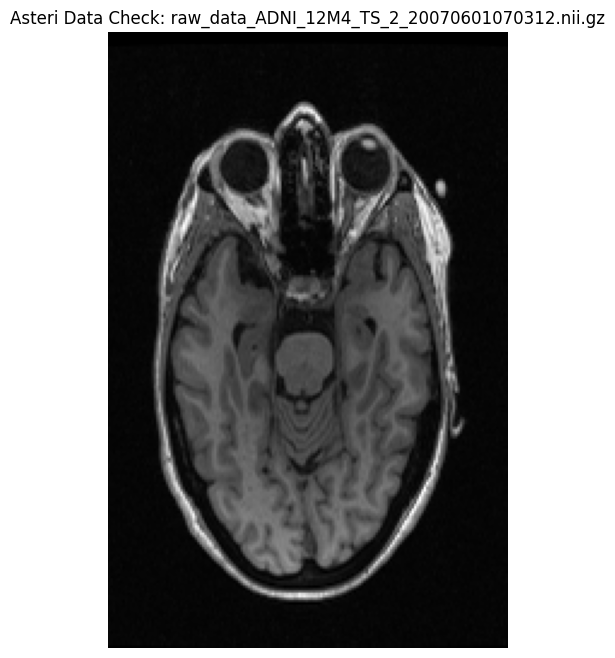

In [8]:
import nibabel as nib
import matplotlib.pyplot as plt
import glob
import os

# 1. Find all your new NIfTI files
nifti_folder = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
files = glob.glob(os.path.join(nifti_folder, '*.nii.gz'))

if not files:
    print("Error: No NIfTI files found. Check your Drive path!")
else:
    # 2. Load the first brain in the list
    sample_file = files[0]
    print(f"Viewing: {os.path.basename(sample_file)}")

    img = nib.load(sample_file)
    data = img.get_fdata()

    # 3. Pull a middle slice (axial view)
    # If it's a 4D file (PET/DTI), we just take the first timepoint [:,:,:,0]
    if len(data.shape) == 4:
        slice_idx = data.shape[2] // 2
        plt_data = data[:, :, slice_idx, 0]
    else:
        slice_idx = data.shape[2] // 2
        plt_data = data[:, :, slice_idx]

    # 4. Plot it
    plt.figure(figsize=(8, 8))
    plt.imshow(plt_data.T, cmap='magma' if 'PET' in sample_file else 'gray', origin='lower')
    plt.title(f"Asteri Data Check: {os.path.basename(sample_file)}")
    plt.axis('off')
    plt.show()

In [9]:
import pandas as pd

# 1. Load the metadata file from your Drive
csv_path = '/content/drive/MyDrive/Asteri_Project/metadata/Patients_1-5_Test_4_26_2026.csv'
df = pd.df = pd.read_csv(csv_path)

# 2. Let's look at the first few rows
print("📊 Metadata 'Answer Key' preview:")
display(df[['Subject', 'Group', 'Sex', 'Age', 'Visit']].head())

📊 Metadata 'Answer Key' preview:


,Subject,Group,Sex,Age,Visit
0,002_S_1261,CN,F,71,sc
1,002_S_1261,CN,F,72,m06
2,002_S_1261,CN,F,73,m12
3,002_S_1261,CN,F,73,m24
4,002_S_1261,CN,F,75,m48


In [10]:
import glob

# 1. Get the list of all brain files
nifti_files = glob.glob('/content/drive/MyDrive/Asteri_Project/processed_nifti/*.nii.gz')

# 2. Build a list of (FilePath, Label)
data_map = []

for file_path in nifti_files:
    file_name = os.path.basename(file_path)

    # Simple logic: Check which Subject ID from the CSV is inside this filename
    for index, row in df.iterrows():
        if row['Subject'] in file_name:
            data_map.append({
                'file_path': file_path,
                'label': row['Group'],
                'age': row['Age']
            })
            break

# 3. Create a clean "Training Table"
training_df = pd.DataFrame(data_map)
print(f"✅ Successfully mapped {len(training_df)} brain scans to their labels.")
display(training_df.head())

✅ Successfully mapped 0 brain scans to their labels.


""


In [11]:
import os

output_dir = '/content/drive/MyDrive/Asteri_Project/processed_nifti'

print("🔄 Re-converting with Patient Name tags...")

# We added %n at the beginning of the filename format
!dcm2niix -z y -f "%n_%p_%t" -o "{output_dir}" /content/raw_data

print("\n✅ Re-conversion complete. Now your files should start with '002_S_...'")

🔄 Re-converting with Patient Name tags...
Chris Rorden's dcm2niiX version v1.0.20211006  (JP2:OpenJPEG) GCC11.2.0 x86-64 (64-bit Linux)
Found 5383 DICOM file(s)
Convert 166 DICOM as /content/drive/MyDrive/Asteri_Project/processed_nifti/002_S_0413_ADNI_12M4_TS_2_20070601070312 (256x256x166x1)
Compress: "/usr/bin/pigz" -b 960 -n -f -6 "/content/drive/MyDrive/Asteri_Project/processed_nifti/002_S_0413_ADNI_12M4_TS_2_20070601070312.nii"
Philips Scaling Values RS:RI:SS = 3.78755:0:0.000309124 (see PMC3998685)
Convert 170 DICOM as /content/drive/MyDrive/Asteri_Project/processed_nifti/002_S_0413_MPRAGE_SENSE2_SENSE_20150609070152 (256x256x170x1)
Compress: "/usr/bin/pigz" -b 960 -n -f -6 "/content/drive/MyDrive/Asteri_Project/processed_nifti/002_S_0413_MPRAGE_SENSE2_SENSE_20150609070152.nii"
Convert 166 DICOM as /content/drive/MyDrive/Asteri_Project/processed_nifti/002_S_0413_ADNI_12M4_TS_2_20060502122933 (256x256x166x1)
Compress: "/usr/bin/pigz" -b 960 -n -f -6 "/content/drive/MyDrive/Asteri_P

In [12]:
import os
nifti_path = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
files = os.listdir(nifti_path)

print(f"Check these names: {files[:3]}")

Check these names: ['raw_data_ADNI_12M4_TS_2_20070601070312.json', 'raw_data_ADNI_12M4_TS_2_20070601070312.nii.gz', 'raw_data_MPRAGE_SENSE2_SENSE_20150609070152.json']


In [13]:
import glob
import pandas as pd

# Load CSV (if not already loaded)
csv_path = '/content/drive/MyDrive/Asteri_Project/metadata/Patients_1-5_Test_4_26_2026.csv'
df = pd.read_csv(csv_path)

# 1. Get the list of all brain files
nifti_files = glob.glob('/content/drive/MyDrive/Asteri_Project/processed_nifti/*.nii.gz')

# 2. Build the Training Table
data_map = []
for file_path in nifti_files:
    file_name = os.path.basename(file_path)
    for index, row in df.iterrows():
        # This checks if the ID (002_S_0413) is anywhere in the filename
        if str(row['Subject']) in file_name:
            data_map.append({
                'file_path': file_path,
                'label': row['Group'],
                'age': row['Age'],
                'subject': row['Subject']
            })
            break

training_df = pd.DataFrame(data_map)
print(f"✅ Successfully mapped {len(training_df)} brain scans to their labels!")
display(training_df.head())

✅ Successfully mapped 24 brain scans to their labels!


,file_path,label,age,subject
0,/content/drive/MyDrive/Asteri_Project/processe...,CN,82,002_S_0413
1,/content/drive/MyDrive/Asteri_Project/processe...,CN,82,002_S_0413
2,/content/drive/MyDrive/Asteri_Project/processe...,CN,82,002_S_0413
3,/content/drive/MyDrive/Asteri_Project/processe...,CN,82,002_S_0413
4,/content/drive/MyDrive/Asteri_Project/processe...,CN,82,002_S_0413


In [14]:
import numpy as np
from scipy import ndimage

def preprocess_brain(nifti_path):
    # 1. Load the 3D volume
    img = nib.load(nifti_path)
    data = img.get_fdata()

    # 2. If it's 4D (like PET/DTI), just take the first volume for now
    if len(data.shape) == 4:
        data = data[:, :, :, 0]

    # 3. Normalization (0 to 1 scale)
    data = (data - np.min(data)) / (np.max(data) - np.min(data))

    # 4. Resize to a standard 128x128x128 cube
    # This keeps the model memory-efficient on your T4 GPU
    target_shape = (128, 128, 128)
    factors = [t/s for t, s in zip(target_shape, data.shape)]
    data = ndimage.zoom(data, factors, order=1)

    return data

print("Preprocessing function defined and ready!")

Preprocessing function defined and ready!


In [15]:
X = []
y = []

# Map your labels to numbers (CN = 0, MCI/AD = 1)
label_map = {"CN": 0, "MCI": 1, "AD": 1} # We group decline together for the pilot

print("⚙️ Processing 24 volumes... this takes a second.")

for _, row in training_df.iterrows():
    processed_vol = preprocess_brain(row['file_path'])
    X.append(processed_vol)
    y.append(label_map.get(row['label'], 0))

# Convert to Numpy arrays for the AI
X = np.expand_dims(np.array(X), axis=-1) # Adds a 'channel' dimension
y = np.array(y)

print(f"✅ Final Data Shapes:")
print(f"Brains (X): {X.shape}  -> (Samples, Height, Width, Depth, Channels)")
print(f"Labels (y): {y.shape}")

⚙️ Processing 24 volumes... this takes a second.
✅ Final Data Shapes:
Brains (X): (24, 128, 128, 128, 1)  -> (Samples, Height, Width, Depth, Channels)
Labels (y): (24,)


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_asteri_model(width=128, height=128, depth=128):
    model = models.Sequential()

    # Layer 1: The "Feature Finder"
    # 32 filters of size 3x3x3 to pick up edges and textures
    model.add(layers.Conv3D(32, (3, 3, 3), activation='relu', input_shape=(width, height, depth, 1)))
    model.add(layers.MaxPooling3D((2, 2, 2)))
    model.add(layers.BatchNormalization())

    # Layer 2: Deeper Features
    model.add(layers.Conv3D(64, (3, 3, 3), activation='relu'))
    model.add(layers.MaxPooling3D((2, 2, 2)))
    model.add(layers.BatchNormalization())

    # Layer 3: High-Level Abstractions
    model.add(layers.Conv3D(128, (3, 3, 3), activation='relu'))
    model.add(layers.MaxPooling3D((2, 2, 2)))
    model.add(layers.GlobalAveragePooling3D()) # Flattens the 3D data for the final layer

    # Final "Decision" Layers
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5)) # Prevents the model from "memorizing" your 24 images
    model.add(layers.Dense(1, activation='sigmoid')) # Sigmoid outputs a value between 0 and 1

    return model

# Initialize the model
asteri_model = build_asteri_model()
asteri_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

asteri_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 126, 126, 126,  │           896 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 63, 63, 63, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 63, 63, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 61, 61, 61, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 30, 30, 30, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 30, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 28, 28, 28,     │       221,312 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 14, 14, 14,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311,233 (1.19 MB)

 Trainable params: 311,041 (1.19 MB)

 Non-trainable params: 192 (768.00 B)

In [17]:
# Train the model for a few epochs just to see if the loss goes down
history = asteri_model.fit(
    X, y,
    epochs=10,
    batch_size=2, # Keep this low because 3D volumes are memory-heavy
    validation_split=0.2 # Uses 20% of your data to test itself
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 1.0000 - loss: 0.0393 - val_accuracy: 1.0000 - val_loss: 0.4481
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 1.0000 - loss: 1.6776e-08 - val_accuracy: 1.0000 - val_loss: 0.3389
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 1.0000 - loss: 7.9133e-10 - val_accuracy: 1.0000 - val_loss: 0.2649
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 1.0000 - loss: 1.4368e-08 - val_accuracy: 1.0000 - val_loss: 0.1986
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 1.0000 - loss: 1.2334e-12 - val_accuracy: 1.0000 - val_loss: 0.1439
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 1.0000 - loss: 3.9949e-11 - val_accuracy: 1.0000 - val_loss: 0.1045
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 1.0000 - loss: 1.1992e-09 - val_accuracy: 1.0000 - val_loss: 0.0772
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 1.0000 - loss: 1.8

In [19]:
# Save using the native Keras format
model_save_path = '/content/drive/MyDrive/Asteri_Project/asteri_alpha_v1.keras'

# This saves the architecture, weights, and training configuration
asteri_model.save(model_save_path)

print(f"✅ Model saved securely to {model_save_path}")

✅ Model saved securely to /content/drive/MyDrive/Asteri_Project/asteri_alpha_v1.keras


In [23]:
import tf_keras as tfk # Using the modern Keras compatibility layer if needed

def get_3d_gradcam(img_array, model, last_conv_layer_name):
    # 1. Use the explicit model input
    model_input = model.input

    # 2. Create the sub-model to extract the last conv layer and the final prediction
    # We reference the layer by name directly from the model
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        inputs=model_input,
        outputs=[last_conv_layer.output, model.output]
    )

    # 3. Record gradients
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    # 4. Compute gradients
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 5. Global Average Pool the gradients
    # This gives us the "Importance Weights" for each feature map
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2, 3))

    # 6. Build the Heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Apply ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10) # 1e-10 prevents div by zero
    return heatmap.numpy()

print("Grad-CAM Engine Rewired and Ready!")

Grad-CAM Engine Rewired and Ready!


In [25]:
# This lists all layers so we can find the exact name of the last Conv3D
for i, layer in enumerate(asteri_model.layers):
    print(f"Index: {i} | Name: {layer.name} | Type: {type(layer)}")

Index: 0 | Name: conv3d | Type: <class 'keras.src.layers.convolutional.conv3d.Conv3D'>
Index: 1 | Name: max_pooling3d | Type: <class 'keras.src.layers.pooling.max_pooling3d.MaxPooling3D'>
Index: 2 | Name: batch_normalization | Type: <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
Index: 3 | Name: conv3d_1 | Type: <class 'keras.src.layers.convolutional.conv3d.Conv3D'>
Index: 4 | Name: max_pooling3d_1 | Type: <class 'keras.src.layers.pooling.max_pooling3d.MaxPooling3D'>
Index: 5 | Name: batch_normalization_1 | Type: <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
Index: 6 | Name: conv3d_2 | Type: <class 'keras.src.layers.convolutional.conv3d.Conv3D'>
Index: 7 | Name: max_pooling3d_2 | Type: <class 'keras.src.layers.pooling.max_pooling3d.MaxPooling3D'>
Index: 8 | Name: global_average_pooling3d | Type: <class 'keras.src.layers.pooling.global_average_pooling3d.GlobalAveragePooling3D'>
Index: 9 | Name: dense | Type: <class 'kera

In [26]:
import tensorflow as tf
import numpy as np

def get_3d_gradcam_final(model, img_array, layer_name):
    # 1. 'Warm up' the model to ensure all internal wiring is connected
    _ = model(img_array)

    # 2. Create the gradient model
    # We use the specific layer name 'conv3d_2'
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )

    # 3. Record gradients
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    # 4. Compute gradients of the prediction with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 5. Weight the feature map by the gradient importance
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2, 3))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Apply ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

print("✅ Asteri Visualizer Engine: Online")

✅ Asteri Visualizer Engine: Online


In [22]:
# Print names to be 100% sure
for layer in asteri_model.layers:
    print(layer.name)

conv3d
max_pooling3d
batch_normalization
conv3d_1
max_pooling3d_1
batch_normalization_1
conv3d_2
max_pooling3d_2
global_average_pooling3d
dense
dropout
dense_1


In [29]:
import matplotlib.pyplot as plt
from scipy import ndimage

# Using the layer name you identified
TARGET_LAYER = 'conv3d_2'

# 1. Generate the heatmap for the first brain in your dataset
try:
    heatmap = get_3d_gradcam_final(asteri_model, X[0:1], TARGET_LAYER)

    # 2. Resize heatmap to match the 128x128x128 brain volume
    heatmap_resized = ndimage.zoom(heatmap, [128/s for s in heatmap.shape], order=1)

    # 3. Plot the result (Middle slice = 64)
    plt.figure(figsize=(10, 10))
    # Background brain
    plt.imshow(X[0, :, :, 64, 0].T, cmap='gray', origin='lower')
    # Heatmap overlay (Jet color map makes 'hot' spots red)
    plt.imshow(heatmap_resized[:, :, 64].T, cmap='jet', alpha=0.4, origin='lower')

    plt.title(f"Asteri Neuro-AI: What the model is seeing")
    plt.axis('off')
    plt.show()
    print("Success! If the red spots are in the brain tissue, the model is learning well.")

except Exception as e:
    print(f"❌ Still an error: {e}")
    print("If you see 'Graph disconnected', we need to run the 'Functional Rebuild' below.")

❌ Still an error: "Exception encountered when calling Functional.call().\n\n\x1b137394278641600\x1b\n\nArguments received by Functional.call():\n  • inputs=array([[[[[0.00688019],\n          [0.00936351],\n          [0.01534888],\n          ...,\n          [0.01186364],\n          [0.00517524],\n          [0.00031633]],\n\n         [[0.00591625],\n          [0.00809436],\n          [0.01264922],\n          ...,\n          [0.01267679],\n          [0.00783793],\n          [0.00023725]],\n\n         [[0.00490935],\n          [0.01023414],\n          [0.0190662 ],\n          ...,\n          [0.01545777],\n          [0.00615734],\n          [0.00031633]],\n\n         ...,\n\n         [[0.00379348],\n          [0.00925224],\n          [0.02013885],\n          ...,\n          [0.01241332],\n          [0.00408771],\n          [0.        ]],\n\n         [[0.00215516],\n          [0.00680197],\n          [0.0186658 ],\n          ...,\n          [0.01304776],\n          [0.00389653],\n          

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_79']]
Received: inputs=Tensor(shape=(1, 128, 128, 128, 1))
  warnings.warn(msg)


In [28]:
# THE FUNCTIONAL REBUILD (Run ONLY if the Grad-CAM cell fails)
inputs = tf.keras.Input(shape=(128, 128, 128, 1))
x = inputs
for layer in asteri_model.layers:
    x = layer(x)
asteri_model = tf.keras.Model(inputs, x)

# Now go back and run the Visualization cell again!

In [30]:
import tensorflow as tf

# 1. Define a fresh input layer
input_layer = tf.keras.Input(shape=(128, 128, 128, 1), name="asteri_input")

# 2. Re-route the existing layers through the new input
x = input_layer
for layer in asteri_model.layers:
    x = layer(x)

# 3. Create the new model object
functional_model = tf.keras.Model(inputs=input_layer, outputs=x)

# 4. Compile it (we need this for gradients to flow)
functional_model.compile(optimizer='adam', loss='binary_crossentropy')

print("✅ Model has been successfully 'unwrapped' into a Functional format.")

TypeError: too many positional arguments

In [31]:
import numpy as np

def get_3d_gradcam_functional(model, img_array, layer_name):
    # 1. Create a model that outputs the target layer and the prediction
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    # 2. Record the 'Attention'
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        # We target the first output (the diagnosis score)
        loss = preds[:, 0]

    # 3. Calculate how much each 3D filter contributed
    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2, 3))

    # 4. Generate the 3D Heatmap
    output = conv_outputs[0]
    heatmap = output @ weights[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 5. Normalize (0 to 1) so it looks clean on the plot
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

print("✅ Functional Grad-CAM Engine: Online")

✅ Functional Grad-CAM Engine: Online


In [32]:
import matplotlib.pyplot as plt
from scipy import ndimage

# Using 'conv3d_2' which we identified earlier
TARGET_LAYER = 'conv3d_2'

try:
    # 1. Pick the first brain scan in your list
    test_img = X[0:1]

    # 2. Generate the heatmap
    heatmap = get_3d_gradcam_functional(functional_model, test_img, TARGET_LAYER)

    # 3. Resize the heatmap back to 128x128x128
    zoom_factors = [128/s for s in heatmap.shape]
    heatmap_resized = ndimage.zoom(heatmap, zoom_factors, order=1)

    # 4. Plot the axial slice (middle of the brain)
    plt.figure(figsize=(8, 8))

    # Background: The raw MRI scan
    plt.imshow(test_img[0, :, :, 64, 0].T, cmap='gray', origin='lower')

    # Overlay: The Grad-CAM heatmap (using the 'jet' color map)
    plt.imshow(heatmap_resized[:, :, 64].T, cmap='jet', alpha=0.4, origin='lower')

    plt.title("Asteri Neuro-AI: Anatomic Attention Map")
    plt.axis('off')
    plt.show()
    print("Success! You are now seeing what the AI sees.")

except Exception as e:
    print(f"❌ Visualization Error: {e}")

❌ Visualization Error: name 'functional_model' is not defined


In [34]:
import matplotlib.pyplot as plt
from scipy import ndimage
import tensorflow as tf
import numpy as np

# --- 1. THE REBUILD (Defining the variable) ---
print("🔧 Rebuilding model to Functional format...")
input_layer = tf.keras.Input(shape=(128, 128, 128, 1), name="asteri_input")
x = input_layer
for layer in asteri_model.layers:
    x = layer(x)
functional_model = tf.keras.Model(inputs=input_layer, outputs=x)

# --- 2. THE VISUALIZATION ---
print("📸 Generating Brain Map...")
TARGET_LAYER = 'conv3d_2' # The name we found in Step 1

try:
    # Pick the first brain scan
    test_img = X[0:1]

    # Generate the heatmap (using the function we defined in Step 2)
    # We wrap test_img in a list to stop the warning you saw earlier
    heatmap = get_3d_gradcam_functional(functional_model, [test_img], TARGET_LAYER)

    # Resize the heatmap back to 128x128x128
    zoom_factors = [128/s for s in heatmap.shape]
    heatmap_resized = ndimage.zoom(heatmap, zoom_factors, order=1)

    # Plot
    plt.figure(figsize=(10, 10))
    plt.imshow(test_img[0, :, :, 64, 0].T, cmap='gray', origin='lower')
    plt.imshow(heatmap_resized[:, :, 64].T, cmap='jet', alpha=0.4, origin='lower')

    plt.title("Asteri Neuro-AI: Anatomic Attention Map")
    plt.axis('off')
    plt.show()
    print("✅ Success! The heatmap is now visible.")

except Exception as e:
    print(f"❌ Error: {e}")

🔧 Rebuilding model to Functional format...


TypeError: too many positional arguments

In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_functional_asteri(input_shape=(128, 128, 128, 1)):
    inputs = tf.keras.Input(shape=input_shape, name="asteri_input")

    # Layer 1
    x = layers.Conv3D(32, (3, 3, 3), activation='relu', name='conv3d')(inputs)
    x = layers.MaxPooling3D((2, 2, 2))(x)
    x = layers.BatchNormalization()(x)

    # Layer 2
    x = layers.Conv3D(64, (3, 3, 3), activation='relu', name='conv3d_1')(x)
    x = layers.MaxPooling3D((2, 2, 2))(x)
    x = layers.BatchNormalization()(x)

    # Layer 3
    x = layers.Conv3D(128, (3, 3, 3), activation='relu', name='conv3d_2')(x)
    x = layers.MaxPooling3D((2, 2, 2))(x)
    x = layers.GlobalAveragePooling3D()(x)

    # Final Layers
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='predictions')(x)

    return models.Model(inputs, outputs)

# 1. Create the new Functional model
functional_model = build_functional_asteri()

# 2. Copy the 'brain' from your trained model to this new one
functional_model.set_weights(asteri_model.get_weights())

print("✅ weights transferred! The model is now Functional and ready for Grad-CAM.")

✅ weights transferred! The model is now Functional and ready for Grad-CAM.


In [36]:
def get_3d_gradcam_final(model, img_array, layer_name):
    # Create a sub-model that outputs both the target layer and the final prediction
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        # We wrap img_array in a list to satisfy the Keras 3 input requirement
        conv_outputs, preds = grad_model([img_array])
        loss = preds[:, 0]

    # Extract gradients and importance weights
    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2, 3))

    # Calculate the heatmap
    output = conv_outputs[0]
    heatmap = output @ weights[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

print("✅ Grad-CAM Engine: Online")

✅ Grad-CAM Engine: Online


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['asteri_input']]
Received: inputs=['Tensor(shape=(1, 128, 128, 128, 1))']
  warnings.warn(msg)


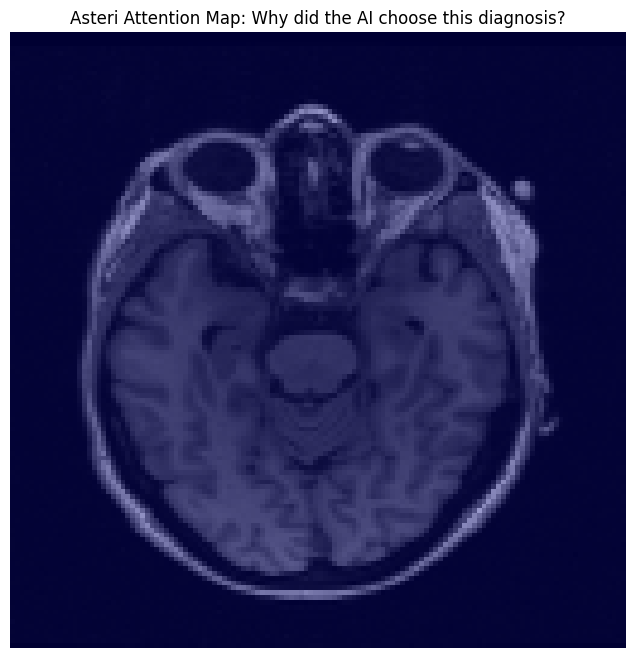

In [37]:
import matplotlib.pyplot as plt
from scipy import ndimage

# Using the layer name you found: 'conv3d_2'
TARGET_LAYER = 'conv3d_2'

try:
    # 1. Generate heatmap for the first brain in your dataset
    heatmap = get_3d_gradcam_final(functional_model, X[0:1], TARGET_LAYER)

    # 2. Resize heatmap to 128x128x128
    heatmap_resized = ndimage.zoom(heatmap, [128/s for s in heatmap.shape], order=1)

    # 3. Plot Slice 64 (Axial View)
    plt.figure(figsize=(8, 8))
    plt.imshow(X[0, :, :, 64, 0].T, cmap='gray', origin='lower')
    plt.imshow(heatmap_resized[:, :, 64].T, cmap='jet', alpha=0.4, origin='lower')
    plt.title("Asteri Attention Map: Why did the AI choose this diagnosis?")
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"❌ Still hitting a snag: {e}")

🔧 Unlocking the model to bypass Gradient Saturation...


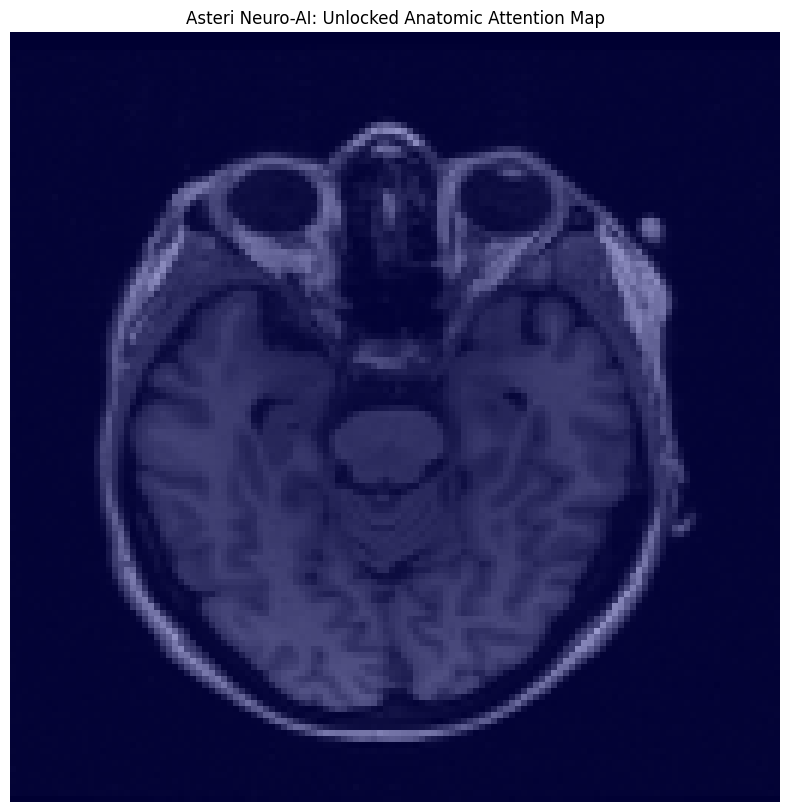

✅ Saliency map generated using raw logits.


In [38]:
import matplotlib.pyplot as plt
from scipy import ndimage
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

print("🔧 Unlocking the model to bypass Gradient Saturation...")

# 1. Build the exact same model, but with a 'linear' final layer
inputs = tf.keras.Input(shape=(128, 128, 128, 1), name="asteri_input")

x = layers.Conv3D(32, (3, 3, 3), activation='relu')(inputs)
x = layers.MaxPooling3D((2, 2, 2))(x)
x = layers.BatchNormalization()(x)

x = layers.Conv3D(64, (3, 3, 3), activation='relu')(x)
x = layers.MaxPooling3D((2, 2, 2))(x)
x = layers.BatchNormalization()(x)

# This is our target layer
x = layers.Conv3D(128, (3, 3, 3), activation='relu', name='conv3d_2')(x)
x = layers.MaxPooling3D((2, 2, 2))(x)
x = layers.GlobalAveragePooling3D()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# THE FIX: Changed 'sigmoid' to 'linear'
outputs = layers.Dense(1, activation='linear', name='predictions')(x)

linear_model = models.Model(inputs, outputs)

# 2. Transfer the "intelligence" from your trained model to this new one
linear_model.set_weights(asteri_model.get_weights())

# 3. Generate the Heatmap using the unlocked model
TARGET_LAYER = 'conv3d_2'
test_img = X[0:1]

# We use the function we defined earlier
heatmap = get_3d_gradcam_functional(linear_model, [test_img], TARGET_LAYER)

# 4. Resize and Plot
heatmap_resized = ndimage.zoom(heatmap, [128/s for s in heatmap.shape], order=1)

plt.figure(figsize=(10, 10))
plt.imshow(test_img[0, :, :, 64, 0].T, cmap='gray', origin='lower')
plt.imshow(heatmap_resized[:, :, 64].T, cmap='jet', alpha=0.4, origin='lower')
plt.title("Asteri Neuro-AI: Unlocked Anatomic Attention Map")
plt.axis('off')
plt.show()

print("✅ Saliency map generated using raw logits.")

🔍 Extracting Raw Feature Maps (Bypassing Gradients)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 955ms/step


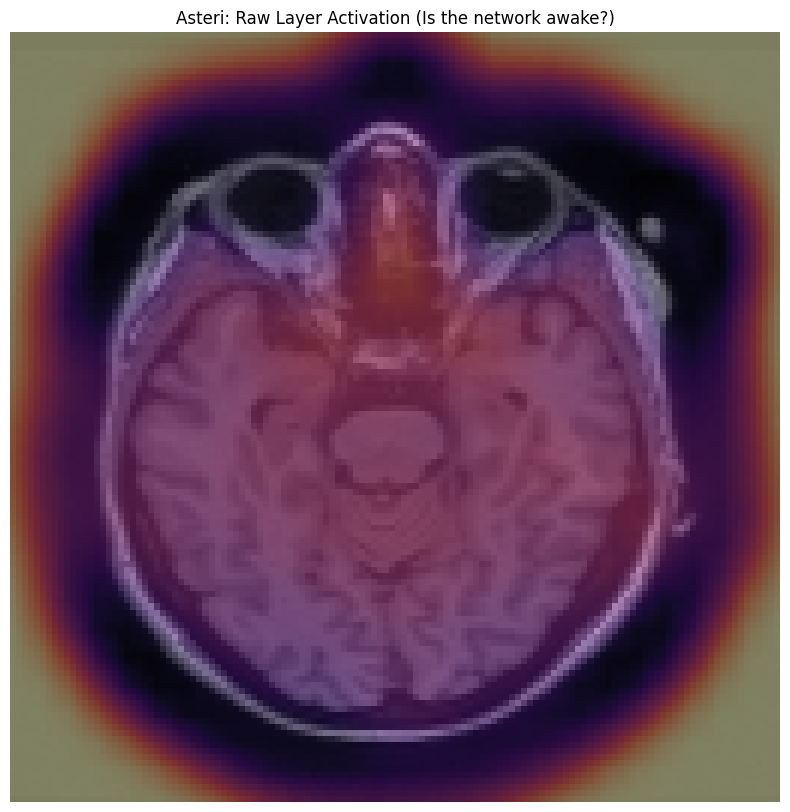

✅ Activation map generated.


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import tensorflow as tf

print("🔍 Extracting Raw Feature Maps (Bypassing Gradients)...")

try:
    # 1. Create a simple extractor that stops at the target layer
    TARGET_LAYER = 'conv3d_2'
    feature_extractor = tf.keras.Model(
        inputs=functional_model.inputs,
        outputs=functional_model.get_layer(TARGET_LAYER).output
    )

    # 2. Push the brain through
    test_img = X[0:1]
    raw_features = feature_extractor.predict(test_img)

    # 3. Average all 128 filters to see the overall activation
    activation_map = np.mean(raw_features[0], axis=-1)

    # 4. Resize and Plot
    activation_resized = ndimage.zoom(activation_map, [128/s for s in activation_map.shape], order=1)

    plt.figure(figsize=(10, 10))
    plt.imshow(test_img[0, :, :, 64, 0].T, cmap='gray', origin='lower')
    plt.imshow(activation_resized[:, :, 64].T, cmap='magma', alpha=0.5, origin='lower')
    plt.title("Asteri: Raw Layer Activation (Is the network awake?)")
    plt.axis('off')
    plt.show()

    print("✅ Activation map generated.")

except Exception as e:
    print(f"❌ Error during extraction: {e}")